## Load and Cleaning


### 1. Load the spatial data table


In [1]:
!pip install pandas shapely numpy geopandas rasterio rasterstats pysal splot seaborn


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [49]:
import pandas as pd
import shapely
import numpy as np
import geopandas as gpd
import seaborn as sns
import rasterio
import re
import matplotlib.pyplot as plt
import os
import esda

from rasterstats import zonal_stats
from libpysal.weights import Queen, lag_spatial
from esda.moran import Moran, Moran_Local
from splot.esda import plot_moran

In [4]:
df = pd.read_csv(r"nuremberg_dataset_final.csv")
df.head()

,band_x,longitude,latitude,label_2020,band_y,label_2021,b3_2020,b4_2020,b8_2020,b11_2020,b3_2021,b4_2021,b8_2021,b11_2021
0,1,10.950042,49.520042,40.0,1.0,40.0,54657.0,12911.0,11502.0,12013.0,33636.0,24478.0,16450.0,18114.0
1,1,10.950042,49.519958,40.0,1.0,40.0,54133.0,11895.0,10289.0,11908.0,35488.0,25494.0,16777.0,19870.0
2,1,10.950042,49.519875,40.0,1.0,40.0,56033.0,9667.0,8880.0,11423.0,35488.0,25494.0,16777.0,19870.0
3,1,10.950042,49.519792,40.0,1.0,40.0,56033.0,9667.0,8880.0,11423.0,42140.0,28803.0,18907.0,22354.0
4,1,10.950042,49.519708,40.0,1.0,40.0,58655.0,8602.0,8651.0,11220.0,43614.0,29262.0,19562.0,22308.0


In [5]:
df.shape

(443164, 14)

### 2. Basic data quality checks

In [6]:
# checking for duplicates

# duplicated values would have the label True (including the first value)
duplicate_grids = df.duplicated(subset=None, keep=False)


if "True" in duplicate_grids:
  print("A duplicate was found!") #shouldnt run 

In [7]:
# making a unique grid_id column 

grid_id = list(range(len(df)))

df.insert(0, "grid_id", grid_id)

In [8]:
df.head()

,grid_id,band_x,longitude,latitude,label_2020,band_y,label_2021,b3_2020,b4_2020,b8_2020,b11_2020,b3_2021,b4_2021,b8_2021,b11_2021
0,0,1,10.950042,49.520042,40.0,1.0,40.0,54657.0,12911.0,11502.0,12013.0,33636.0,24478.0,16450.0,18114.0
1,1,1,10.950042,49.519958,40.0,1.0,40.0,54133.0,11895.0,10289.0,11908.0,35488.0,25494.0,16777.0,19870.0
2,2,1,10.950042,49.519875,40.0,1.0,40.0,56033.0,9667.0,8880.0,11423.0,35488.0,25494.0,16777.0,19870.0
3,3,1,10.950042,49.519792,40.0,1.0,40.0,56033.0,9667.0,8880.0,11423.0,42140.0,28803.0,18907.0,22354.0
4,4,1,10.950042,49.519708,40.0,1.0,40.0,58655.0,8602.0,8651.0,11220.0,43614.0,29262.0,19562.0,22308.0


In [9]:
df.isna()

,grid_id,band_x,longitude,latitude,label_2020,band_y,label_2021,b3_2020,b4_2020,b8_2020,b11_2020,b3_2021,b4_2021,b8_2021,b11_2021
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443159,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
443160,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
443161,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
443162,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
missing_data = df.loc[443163] # accounts for cloud cover and missing data issue

In [11]:
missing_data.head()

grid_id       443163.0
band_x             1.0
longitude         10.0
latitude           NaN
label_2020         NaN
Name: 443163, dtype: float64

In [12]:
df = df.dropna()

## Feature and Engineering

### 1. Compute spectral indices (NDVI, NDBI)

NDVI of every point will be calculated by the equation: 

\begin{equation}
NDVI = \frac{NIR - Red}{NIR + Red}
\end{equation}

In [13]:
def nvdi(nir, red):
  return (nir - red)/(nir + red)

Same goes for NDBI:

\begin{equation}
NDBI = \frac{SWIR - NIR}{SWIR + NIR}
\end{equation}

In [14]:
def ndbi(nir, swir):
  return (swir - nir)/(swir + nir)


In [15]:
# NDVI for vegetation intensity
df["ndvi_2020"] = nvdi(df['b8_2020'], df['b4_2020'])
df["ndvi_2021"] = nvdi(df['b8_2021'], df['b4_2021'])

# NDBI for built-up intensity
df["ndbi_2020"] = nvdi(df['b8_2020'], df['b11_2020'])
df["ndbi_2021"] = nvdi(df['b8_2021'], df['b11_2021'])


In [16]:
df.head()

,grid_id,band_x,longitude,latitude,label_2020,band_y,label_2021,b3_2020,b4_2020,b8_2020,b11_2020,b3_2021,b4_2021,b8_2021,b11_2021,ndvi_2020,ndvi_2021,ndbi_2020,ndbi_2021
0,0,1,10.950042,49.520042,40.0,1.0,40.0,54657.0,12911.0,11502.0,12013.0,33636.0,24478.0,16450.0,18114.0,-0.057715,-0.196149,-0.021731,-0.048143
1,1,1,10.950042,49.519958,40.0,1.0,40.0,54133.0,11895.0,10289.0,11908.0,35488.0,25494.0,16777.0,19870.0,-0.072395,-0.206217,-0.072938,-0.084400
2,2,1,10.950042,49.519875,40.0,1.0,40.0,56033.0,9667.0,8880.0,11423.0,35488.0,25494.0,16777.0,19870.0,-0.042433,-0.206217,-0.125252,-0.084400
3,3,1,10.950042,49.519792,40.0,1.0,40.0,56033.0,9667.0,8880.0,11423.0,42140.0,28803.0,18907.0,22354.0,-0.042433,-0.207420,-0.125252,-0.083541
4,4,1,10.950042,49.519708,40.0,1.0,40.0,58655.0,8602.0,8651.0,11220.0,43614.0,29262.0,19562.0,22308.0,0.002840,-0.198673,-0.129284,-0.065584


### 2. Extract ESA WorldCover proportions

#### Downloading Data

You can find the link to the ESA-WorldCover Datasets Repo [here](https://github.com/ESA-WorldCover/esa-worldcover-datasets) which has the details for downloading the ESA WorldCover for Nuremberg area

In [17]:
min_lon = df["longitude"].min()
min_lat = df["latitude"].min()

max_lon = df["longitude"].max()
max_lat = df["latitude"].max()

In [18]:
print(f"Bounding box: {min_lon} {min_lat} {max_lon} {max_lat}")

Bounding box: 10.950041666666666 49.38004166666666 10.971958333333331 49.52004166666666


In [19]:
!python download.py -b {min_lon} {min_lat} {max_lon} {max_lat}

^C


In [20]:
!python download.py -b {min_lon} {min_lat} {max_lon} {max_lat} -y 2020

100%|█████████████████████████████████████████████| 1/1 [00:04<00:00,  4.93s/it]


#### Creating Polygons from Grids

In [20]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["longitude"], df["latitude"]), crs="EPSG:4326")

In [21]:
gdf.head()

,grid_id,band_x,longitude,latitude,label_2020,band_y,label_2021,b3_2020,b4_2020,b8_2020,b11_2020,b3_2021,b4_2021,b8_2021,b11_2021,ndvi_2020,ndvi_2021,ndbi_2020,ndbi_2021,geometry
0,0,1,10.950042,49.520042,40.0,1.0,40.0,54657.0,12911.0,11502.0,12013.0,33636.0,24478.0,16450.0,18114.0,-0.057715,-0.196149,-0.021731,-0.048143,POINT (10.95004 49.52004)
1,1,1,10.950042,49.519958,40.0,1.0,40.0,54133.0,11895.0,10289.0,11908.0,35488.0,25494.0,16777.0,19870.0,-0.072395,-0.206217,-0.072938,-0.084400,POINT (10.95004 49.51996)
2,2,1,10.950042,49.519875,40.0,1.0,40.0,56033.0,9667.0,8880.0,11423.0,35488.0,25494.0,16777.0,19870.0,-0.042433,-0.206217,-0.125252,-0.084400,POINT (10.95004 49.51988)
3,3,1,10.950042,49.519792,40.0,1.0,40.0,56033.0,9667.0,8880.0,11423.0,42140.0,28803.0,18907.0,22354.0,-0.042433,-0.207420,-0.125252,-0.083541,POINT (10.95004 49.51979)
4,4,1,10.950042,49.519708,40.0,1.0,40.0,58655.0,8602.0,8651.0,11220.0,43614.0,29262.0,19562.0,22308.0,0.002840,-0.198673,-0.129284,-0.065584,POINT (10.95004 49.51971)


In [22]:
gdf.isna()

,grid_id,band_x,longitude,latitude,label_2020,band_y,label_2021,b3_2020,b4_2020,b8_2020,b11_2020,b3_2021,b4_2021,b8_2021,b11_2021,ndvi_2020,ndvi_2021,ndbi_2020,ndbi_2021,geometry
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443158,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
443159,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
443160,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
443161,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [23]:
# Code implementation from https://stackoverflow.com/questions/68365255/convert-latitude-longitude-points-to-grid-polygons-in-geopandas

def get_square_around_point(point_geom, delta_size=0.0005):

    point_coords = np.array(point_geom.coords[0])

    c1 = point_coords + [-delta_size,-delta_size]
    c2 = point_coords + [-delta_size,+delta_size]
    c3 = point_coords + [+delta_size,+delta_size]
    c4 = point_coords + [+delta_size,-delta_size]

    square_geom = shapely.geometry.Polygon([c1,c2,c3,c4])

    return square_geom

In [24]:
def get_gdf_with_squares(gdf_with_points, delta_size=0.0005):
    gdf_squares = gdf_with_points.copy()
    gdf_squares['geometry'] = (gdf_with_points['geometry'].astype(object)  
                               .apply(lambda geom: get_square_around_point(geom, delta_size)))

    return gdf_squares

In [25]:
gdf_squares = get_gdf_with_squares(gdf, delta_size=0.0005)

In [26]:
gdf_squares.head()

,grid_id,band_x,longitude,latitude,label_2020,band_y,label_2021,b3_2020,b4_2020,b8_2020,b11_2020,b3_2021,b4_2021,b8_2021,b11_2021,ndvi_2020,ndvi_2021,ndbi_2020,ndbi_2021,geometry
0,0,1,10.950042,49.520042,40.0,1.0,40.0,54657.0,12911.0,11502.0,12013.0,33636.0,24478.0,16450.0,18114.0,-0.057715,-0.196149,-0.021731,-0.048143,"POLYGON ((10.94954 49.51954, 10.94954 49.52054..."
1,1,1,10.950042,49.519958,40.0,1.0,40.0,54133.0,11895.0,10289.0,11908.0,35488.0,25494.0,16777.0,19870.0,-0.072395,-0.206217,-0.072938,-0.084400,"POLYGON ((10.94954 49.51946, 10.94954 49.52046..."
2,2,1,10.950042,49.519875,40.0,1.0,40.0,56033.0,9667.0,8880.0,11423.0,35488.0,25494.0,16777.0,19870.0,-0.042433,-0.206217,-0.125252,-0.084400,"POLYGON ((10.94954 49.51938, 10.94954 49.52038..."
3,3,1,10.950042,49.519792,40.0,1.0,40.0,56033.0,9667.0,8880.0,11423.0,42140.0,28803.0,18907.0,22354.0,-0.042433,-0.207420,-0.125252,-0.083541,"POLYGON ((10.94954 49.51929, 10.94954 49.52029..."
4,4,1,10.950042,49.519708,40.0,1.0,40.0,58655.0,8602.0,8651.0,11220.0,43614.0,29262.0,19562.0,22308.0,0.002840,-0.198673,-0.129284,-0.065584,"POLYGON ((10.94954 49.51921, 10.94954 49.52021..."


In [27]:
gdf_squares.isna()

,grid_id,band_x,longitude,latitude,label_2020,band_y,label_2021,b3_2020,b4_2020,b8_2020,b11_2020,b3_2021,b4_2021,b8_2021,b11_2021,ndvi_2020,ndvi_2021,ndbi_2020,ndbi_2021,geometry
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443158,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
443159,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
443160,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
443161,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [28]:
# ESA WorldCover 11 Land Cover Classes
classes = {10: "Tree cover",
           20: "Shrubland",
           30: "Grassland",
           40: "Cropland",
           50: "Built up",
           60: "Bare / sparse vegetation",
           70: "Snow and Ice",
           80: "Permanent water bodies",
           90	:"Herbaceous wetland",
           95	:"Mangroves",
           100 :"Moss and lichen",
           0:	"No data"}

In [29]:
def extract_proportions(gdf_squares, classes, wc_tif) -> pd.DataFrame:
    wc_stats = zonal_stats(gdf_squares, wc_tif, stats="count", categorical=True, category_map=classes)
    df = pd.DataFrame(wc_stats)
    df = df.fillna(0)
    total_pixels = df['count']
    for _, original_name in classes.items():
        if original_name in df.columns:
            clean_name = re.sub(r"[^\w\s]", '', original_name)
            clean_name = re.sub(r"\s+", '_', clean_name).lower()

            df[f"{clean_name}_prop"] = df[original_name] / total_pixels

    return df

In [30]:
#  uncomment if you dont have parquet file (note it takes time, drink some tea)
# wc_stats_2020 = extract_proportions(gdf_squares, classes, "ESA_WorldCover_10m_2020_v100_N48E009_Map.tif")

In [31]:
wc_stats_2020 = pd.read_parquet(r"wc_stats_2020.parquet")

In [32]:
wc_stats_2020.head()

,Grassland,Cropland,count,Bare / sparse vegetation,Tree cover,Built up,Permanent water bodies,Herbaceous wetland,tree_cover_prop,grassland_prop,cropland_prop,built_up_prop,bare_sparse_vegetation_prop,permanent_water_bodies_prop,herbaceous_wetland_prop
0,2.0,154.0,156,0.0,0.0,0.0,0.0,0.0,0.0,0.012821,0.987179,0.0,0.0,0.0,0.0
1,2.0,167.0,169,0.0,0.0,0.0,0.0,0.0,0.0,0.011834,0.988166,0.0,0.0,0.0,0.0
2,0.0,169.0,169,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.0,0.0,0.0,0.0
3,0.0,169.0,169,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.0,0.0,0.0,0.0
4,0.0,169.0,169,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.0,0.0,0.0,0.0


In [33]:
# table_2020 = pa.Table.from_pandas(wc_stats_2020)
# pq.write_table(table_2020, 'wc_stats_2020.parquet')

In [34]:
# uncomment if you dont have parquet file (note it takes time, get tea)
# wc_stats_2021 = extract_proportions(gdf_squares, classes, "ESA_WorldCover_10m_2021_v200_N48E009_Map.tif")

In [35]:
wc_stats_2021 = pd.read_parquet(r"wc_stats_2021.parquet")

In [36]:
wc_stats_2021.head()

,Cropland,count,Grassland,Tree cover,Built up,Permanent water bodies,Bare / sparse vegetation,tree_cover_prop,grassland_prop,cropland_prop,built_up_prop,bare_sparse_vegetation_prop,permanent_water_bodies_prop
0,156.0,156,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,169.0,169,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,169.0,169,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,169.0,169,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,169.0,169,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [37]:
# table_2021 = pa.Table.from_pandas(wc_stats_2021)
# pq.write_table(table_2021, 'wc_stats_2021.parquet')

### 3. Create temporal difference features

In [38]:
df["delta_ndvi"] = df["ndvi_2021"] - df["ndvi_2020"] #change in ndvi
df["delta_ndbi"] = df["ndbi_2021"] - df["ndbi_2020"] #change in ndbi

# change in built up
df["delta_built_up"] = wc_stats_2021["built_up_prop"] - wc_stats_2020["built_up_prop"]

#change in vegetation state
df["delta_veg"] = wc_stats_2021["Bare / sparse vegetation"] - wc_stats_2020["Bare / sparse vegetation"] 

In [39]:
df.tail()

,grid_id,band_x,longitude,latitude,label_2020,band_y,label_2021,b3_2020,b4_2020,b8_2020,...,b8_2021,b11_2021,ndvi_2020,ndvi_2021,ndbi_2020,ndbi_2021,delta_ndvi,delta_ndbi,delta_built_up,delta_veg
443158,443158,1,10.971958,49.432125,10.0,1.0,10.0,44040.0,9830.0,10371.0,...,9798.0,12714.0,0.026781,0.118812,-0.163258,-0.129531,0.092032,0.033727,0.192308,0.0
443159,443159,1,10.971958,49.432042,10.0,1.0,10.0,47727.0,9257.0,10469.0,...,10912.0,12878.0,0.061442,-0.102410,-0.136364,-0.082640,-0.163852,0.053724,0.205128,0.0
443160,443160,1,10.971958,49.431958,10.0,1.0,10.0,47727.0,9257.0,10469.0,...,10912.0,12878.0,0.061442,-0.102410,-0.136364,-0.082640,-0.163852,0.053724,0.217949,0.0
443161,443161,1,10.971958,49.431875,10.0,1.0,10.0,36028.0,11469.0,9077.0,...,7864.0,12688.0,-0.116422,-0.031288,-0.191214,-0.234722,0.085133,-0.043507,0.243590,0.0
443162,443162,1,10.971958,49.431792,30.0,1.0,50.0,37323.0,14107.0,10813.0,...,13664.0,12799.0,-0.132183,0.071981,-0.103994,0.032687,0.204164,0.136681,0.262821,0.0


### 4. Exploratory analysis + visualizations (plots were made with the assitance of [perplexity ai](https://www.perplexity.ai/))

#### Seasonal Variation Check

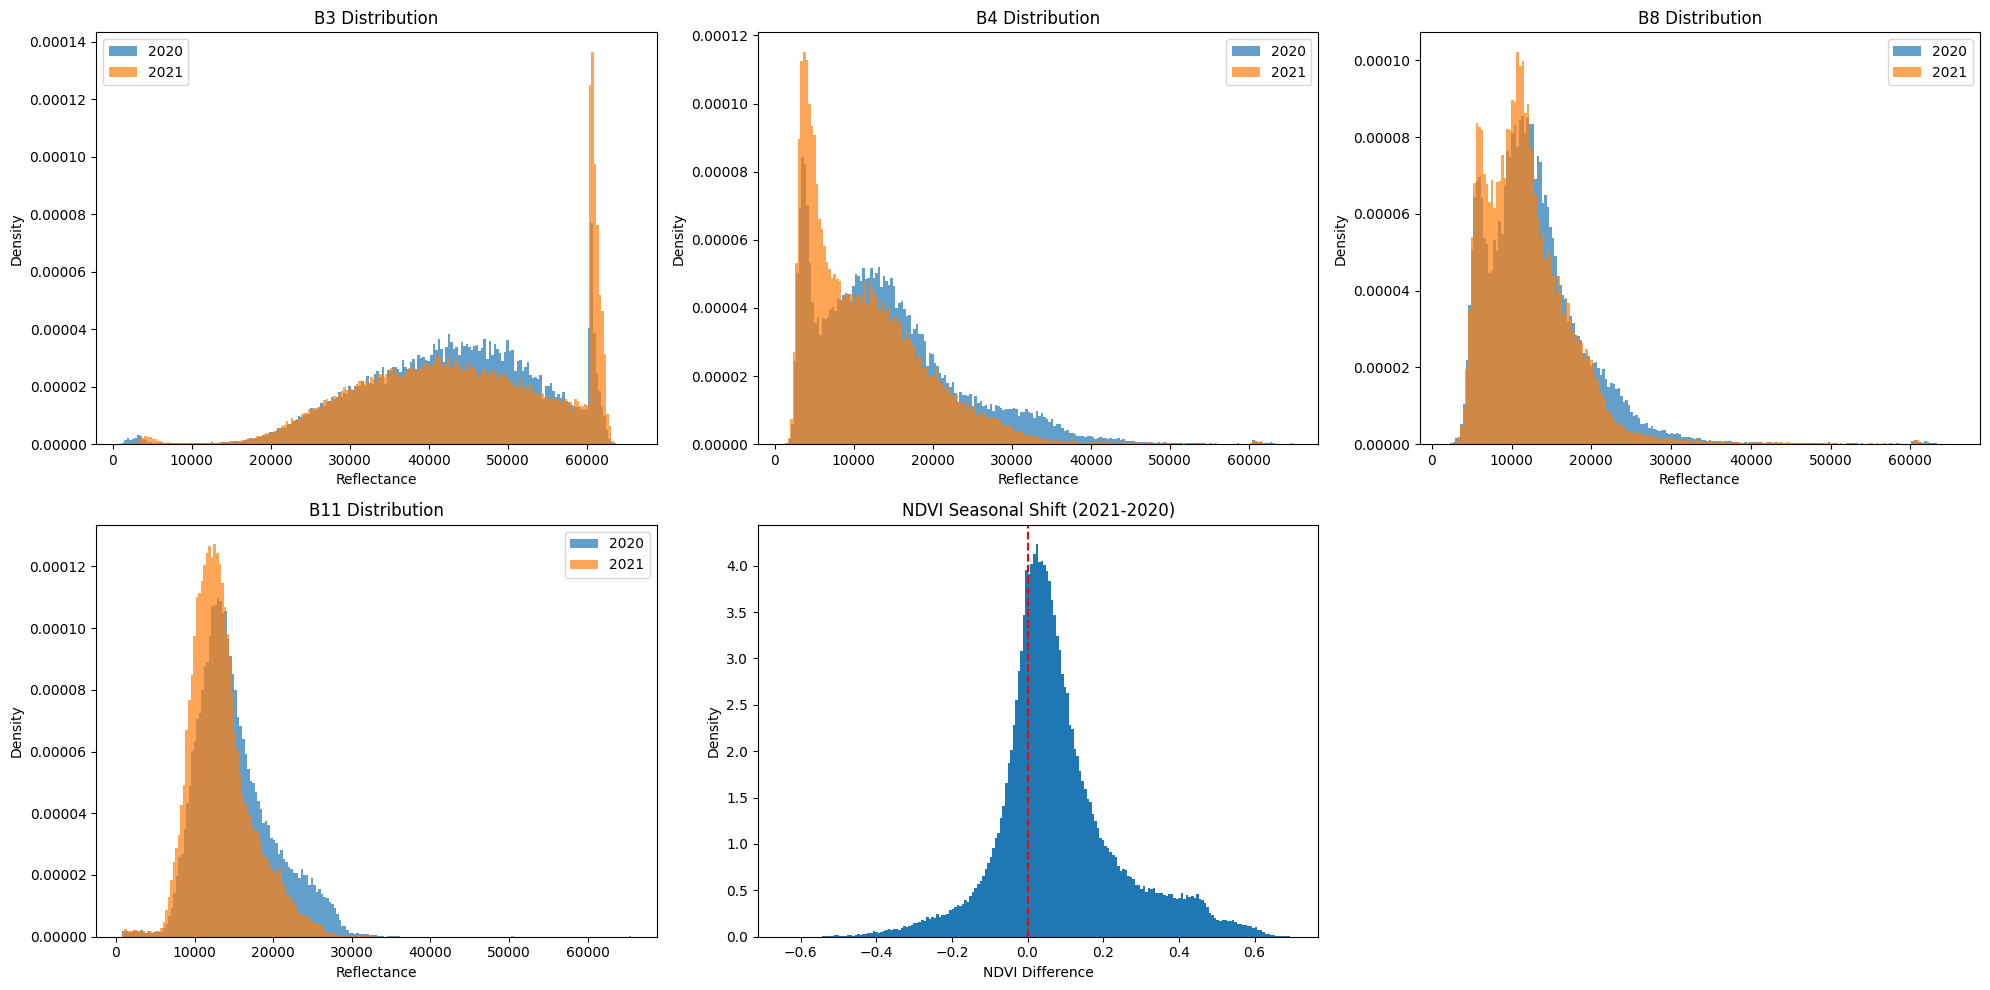

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

bands = ['b3', 'b4', 'b8', 'b11']

for i, band in enumerate(bands):
    row, col = 0, i 
    if i >= 3:  # for figure visuals
        row, col = 1, 0
    axes[row, col].hist(df[f'{band}_2020'], alpha=0.7, label='2020', bins=200, density=True)
    axes[row, col].hist(df[f'{band}_2021'], alpha=0.7, label='2021', bins=200, density=True)
    axes[row, col].set_title(f'{band.upper()} Distribution')
    axes[row, col].set_xlabel("Reflectance")
    axes[row, col].set_ylabel("Density")
    axes[row, col].legend()

# representing delta ndvi
axes[1,1].hist(df["delta_ndvi"], bins=200, density=True)
axes[1,1].axvline(0, color='red', linestyle='--')
axes[1,1].set_title('NDVI Seasonal Shift (2021-2020)')
axes[1,1].set_xlabel("NDVI Difference")
axes[1,1].set_ylabel("Density")

# remove unused subplot 
fig.delaxes(axes[1,2])

plt.tight_layout()
plt.savefig('seasonal_variation_check.png', dpi=300, bbox_inches='tight')
plt.show()

#### Spatial resolution mismatch

In [41]:
with rasterio.open("ESA_WorldCover_10m_2020_v100_N48E009_Map.tif") as src:
    print("pixel size:", src.res)
    print("width x height:", src.width, "x", src.height)

pixel size: (8.333333333333333e-05, 8.333333333333333e-05)
width x height: 36000 x 36000


In [42]:
with rasterio.open("ESA_WorldCover_10m_2021_v200_N48E009_Map.tif") as src:
    print("pixel size:", src.res)
    print("width x height:", src.width, "x", src.height)

pixel size: (8.333333333333333e-05, 8.333333333333333e-05)
width x height: 36000 x 36000


No mismatch found

#### Label behaviors

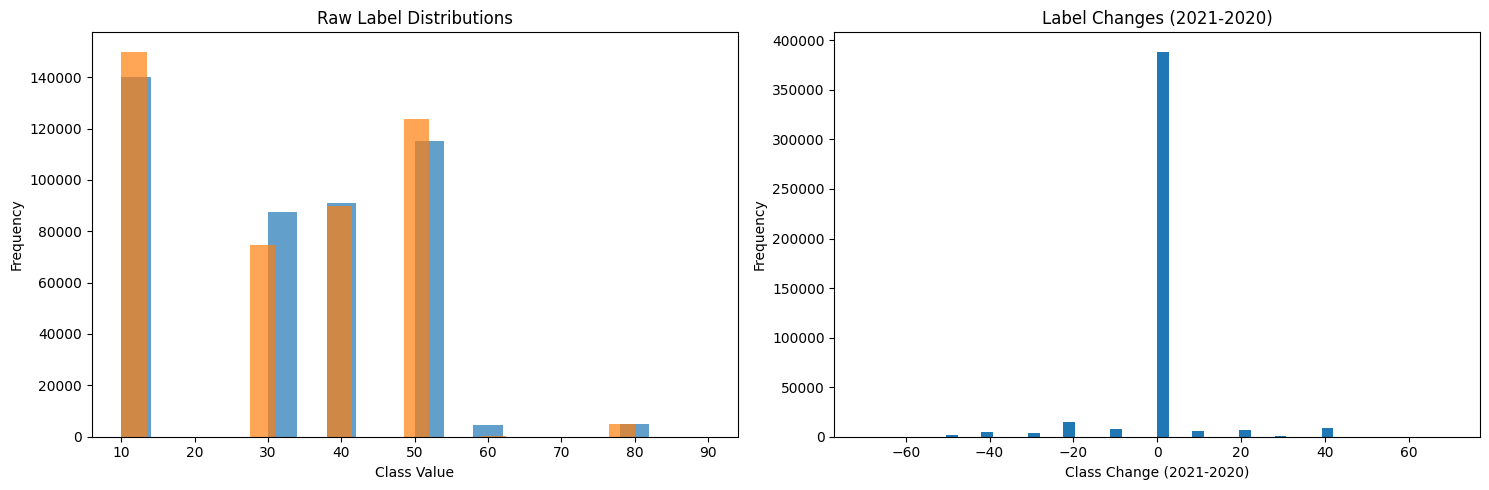

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['label_2020'], bins=20, alpha=0.7, label='2020')
axes[0].hist(df['label_2021'], bins=20, alpha=0.7, label='2021')
axes[0].set_xlabel("Class Value")
axes[0].set_ylabel("Frequency")
axes[0].set_title('Raw Label Distributions')

# changes in labels between 2020 and 2021
df['label_change'] = df['label_2021'] - df['label_2020']
axes[1].hist(df['label_change'], bins=50)
axes[1].set_title('Label Changes (2021-2020)')
axes[1].set_xlabel("Class Change (2021-2020)")
axes[1].set_ylabel("Frequency")


plt.tight_layout()
plt.savefig('label_behavior.png', dpi=300)
plt.show()

#### Spatial autocorrelation (following [this implementation](https://towardsdatascience.com/analyzing-geospatial-data-with-python-part-2-hypothesis-test-fe3f3f18fc82/))

In [44]:
# Generate weights Matrix W from the Geo Data
w = Queen.from_dataframe(gdf)

/tmp/ipykernel_2910/3400441235.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


In [50]:
w.transform = 'R'

In [51]:
for col in ['ndvi_2020', 'ndvi_2021', 'ndbi_2020', 'ndbi_2021']:
    gdf[f'{col}_lag'] = lag_spatial(w, gdf[col])

In [52]:
gdf.head()

,grid_id,band_x,longitude,latitude,label_2020,band_y,label_2021,b3_2020,b4_2020,b8_2020,...,b11_2021,ndvi_2020,ndvi_2021,ndbi_2020,ndbi_2021,geometry,ndvi_2020_lag,ndvi_2021_lag,ndbi_2020_lag,ndbi_2021_lag
0,0,1,10.950042,49.520042,40.0,1.0,40.0,54657.0,12911.0,11502.0,...,18114.0,-0.057715,-0.196149,-0.021731,-0.048143,POINT (10.95004 49.52004),-0.067406,-0.202861,-0.075895,-0.072314
1,1,1,10.950042,49.519958,40.0,1.0,40.0,54133.0,11895.0,10289.0,...,19870.0,-0.072395,-0.206217,-0.072938,-0.084400,POINT (10.95004 49.51996),-0.057880,-0.202190,-0.085021,-0.069897
2,2,1,10.950042,49.519875,40.0,1.0,40.0,56033.0,9667.0,8880.0,...,19870.0,-0.042433,-0.206217,-0.125252,-0.084400,POINT (10.95004 49.51988),-0.059397,-0.206698,-0.110081,-0.084056
3,3,1,10.950042,49.519792,40.0,1.0,40.0,56033.0,9667.0,8880.0,...,22354.0,-0.042433,-0.207420,-0.125252,-0.083541,POINT (10.95004 49.51979),-0.030966,-0.203440,-0.123161,-0.076702
4,4,1,10.950042,49.519708,40.0,1.0,40.0,58655.0,8602.0,8651.0,...,22308.0,0.002840,-0.198673,-0.129284,-0.065584,POINT (10.95004 49.51971),-0.018358,-0.202172,-0.121389,-0.072767


Moran’s I is a statistic that measures the Global correlation between all the points in the space, when compared to its neighbors. 

While the Global spatial autocorrelation returns a single value with Moran’s I statistic, showing the trend of the data spatial distribution, the Local Spatial Autocorrelation will return one value for each point, measuring the relationship of each point with it’s surroundings.

In [53]:
# 2020 NDVI

moran_stat_2020_ndvi = esda.moran.Moran(gdf['ndvi_2020'], w)
print(f"Moran's I 2020 ndvi version: {moran_stat_2020_ndvi.I}")
print(f"Moran's I p-Value 2020 ndvi version: {moran_stat_2020_ndvi.p_sim}")

Moran's I 2020 ndvi version: 0.8809669855509243
Moran's I p-Value 2020 ndvi version: 0.001


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Reference Distribution'}, xlabel='Moran I: 0.88', ylabel='Density'>,
        <Axes: title={'center': 'Moran Scatterplot (0.88)'}, xlabel='Attribute', ylabel='Spatial Lag'>],
       dtype=object))

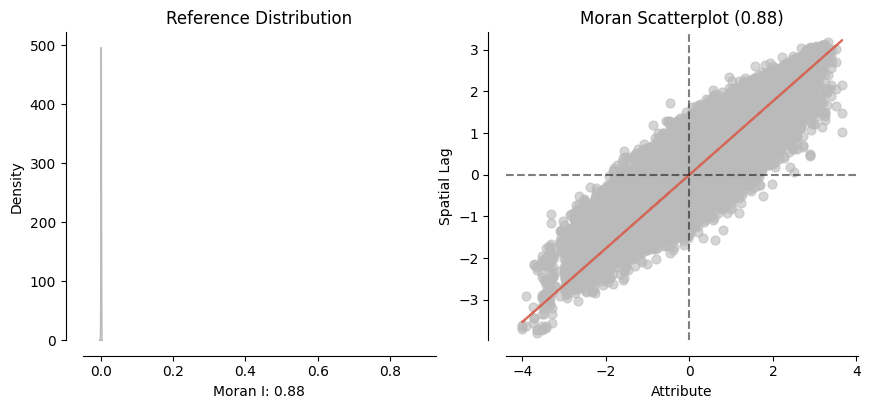

In [54]:
plot_moran(moran_stat_2020_ndvi)

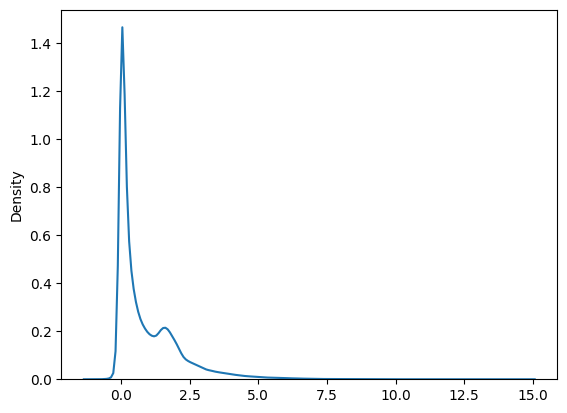

In [55]:
ndvi_local_I_2020_ndvi = esda.moran.Moran_Local(gdf['ndvi_2020'], w)

sns.kdeplot(ndvi_local_I_2020_ndvi.Is);

In [56]:
# 2020 NDBI

moran_stat_2020_ndbi = esda.moran.Moran(gdf['ndbi_2020'], w)
print(f"Moran's I 2020 ndbi version: {moran_stat_2020_ndbi.I}")
print(f"Moran's I p-Value 2020 ndbi version: {moran_stat_2020_ndbi.p_sim}")

Moran's I 2020 ndbi version: 0.8159136613635268
Moran's I p-Value 2020 ndbi version: 0.001


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Reference Distribution'}, xlabel='Moran I: 0.82', ylabel='Density'>,
        <Axes: title={'center': 'Moran Scatterplot (0.82)'}, xlabel='Attribute', ylabel='Spatial Lag'>],
       dtype=object))

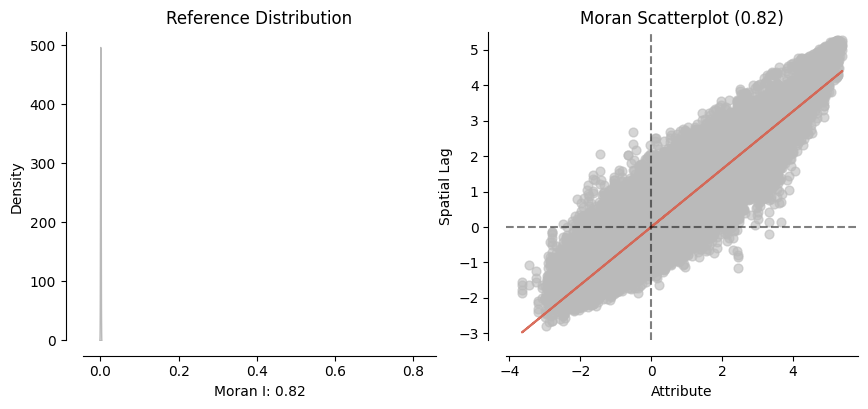

In [57]:
plot_moran(moran_stat_2020_ndbi)

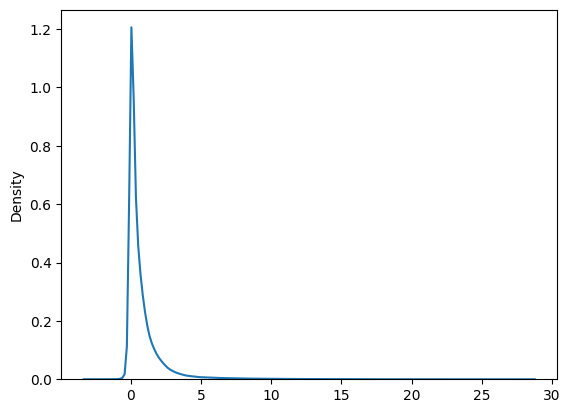

In [58]:
ndvi_local_I_2020_ndbi = esda.moran.Moran_Local(gdf['ndbi_2020'], w)

sns.kdeplot(ndvi_local_I_2020_ndbi.Is);

In [59]:
# 2021 NDVI

moran_stat_2021_ndvi = esda.moran.Moran(gdf['ndvi_2021'], w)
print(f"Moran's I 2021 ndvi version: {moran_stat_2021_ndvi.I}")
print(f"Moran's I p-Value 2021 ndvi version: {moran_stat_2021_ndvi.p_sim}")

Moran's I 2021 ndvi version: 0.8744064246669347
Moran's I p-Value 2021 ndvi version: 0.001


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Reference Distribution'}, xlabel='Moran I: 0.87', ylabel='Density'>,
        <Axes: title={'center': 'Moran Scatterplot (0.87)'}, xlabel='Attribute', ylabel='Spatial Lag'>],
       dtype=object))

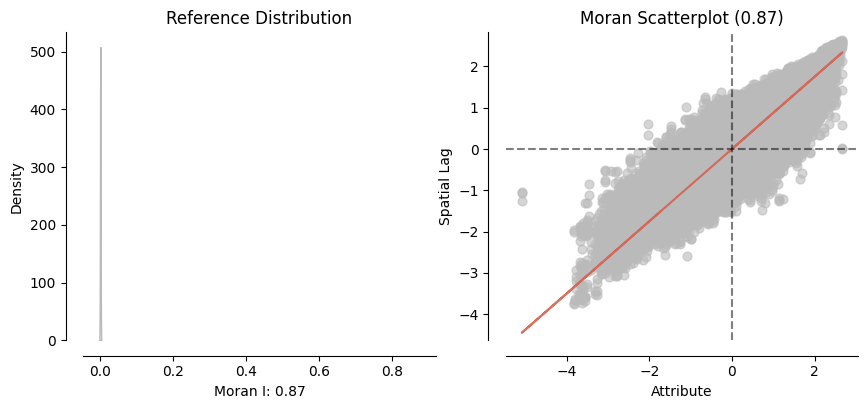

In [60]:
plot_moran(moran_stat_2021_ndvi)

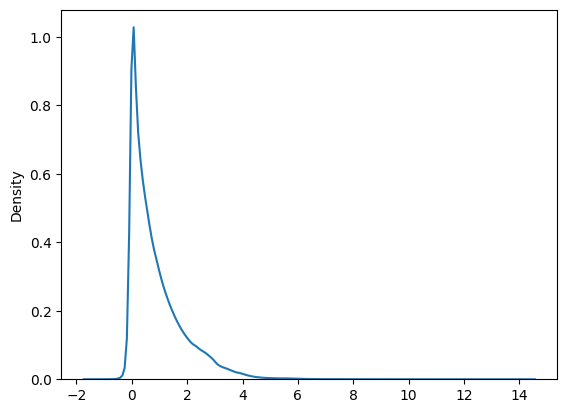

In [61]:
ndvi_local_I_2021_ndvi = esda.moran.Moran_Local(gdf['ndvi_2021'], w)

sns.kdeplot(ndvi_local_I_2021_ndvi.Is);

In [62]:
# 2021 NDBI

moran_stat_2021_ndbi = esda.moran.Moran(gdf['ndbi_2021'], w)
print(f"Moran's I 2021 ndbi version: {moran_stat_2021_ndbi.I}")
print(f"Moran's I p-Value 2021 ndbi version: {moran_stat_2021_ndbi.p_sim}")

Moran's I 2021 ndbi version: 0.8148476576223834
Moran's I p-Value 2021 ndbi version: 0.001


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Reference Distribution'}, xlabel='Moran I: 0.81', ylabel='Density'>,
        <Axes: title={'center': 'Moran Scatterplot (0.81)'}, xlabel='Attribute', ylabel='Spatial Lag'>],
       dtype=object))

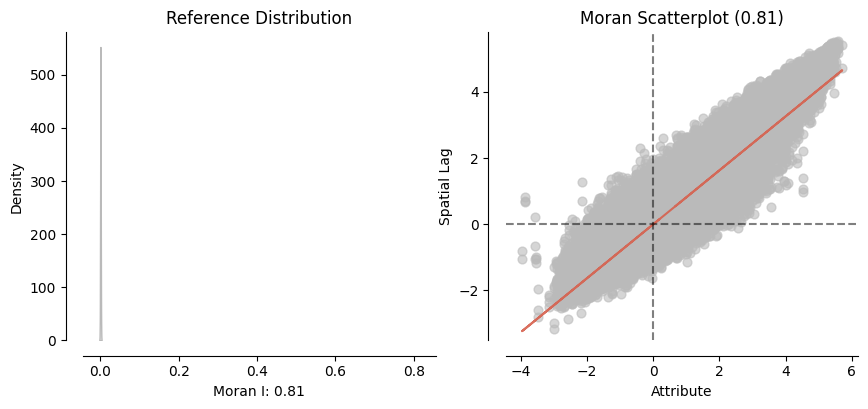

In [63]:
plot_moran(moran_stat_2021_ndbi)

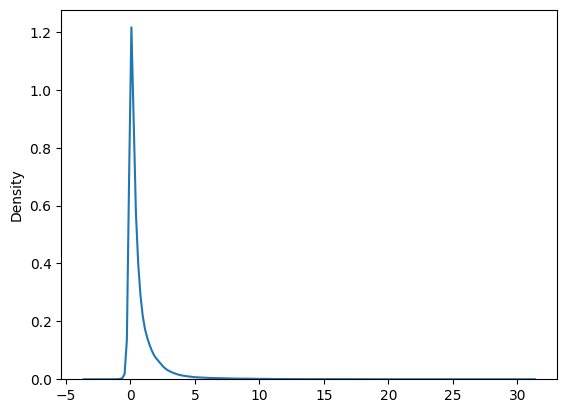

In [64]:
ndvi_local_I_2021_ndbi = esda.moran.Moran_Local(gdf['ndbi_2021'], w)

sns.kdeplot(ndvi_local_I_2021_ndbi.Is);

#### As well as the missing data that was mentioned above

In [66]:
missing_data

grid_id       443163.0
band_x             1.0
longitude         10.0
latitude           NaN
label_2020         NaN
band_y             NaN
label_2021         NaN
b3_2020            NaN
b4_2020            NaN
b8_2020            NaN
b11_2020           NaN
b3_2021            NaN
b4_2021            NaN
b8_2021            NaN
b11_2021           NaN
Name: 443163, dtype: float64

## Creating Labels

### 1. Define and compute labels for 3 tasks

In [67]:
threshold = 0.05 

In [68]:
df["changing_areas"] = np.abs(df["delta_built_up"]) > threshold # is this area stable or changing ?
df["built_up_increase"] = df["delta_built_up"] > threshold # is there an increase in built up in the area?
df["vegetation_decline"] = df["delta_veg"] < 0.0 # is there a decline in vegetation in the area?

In [69]:
df.head()

,grid_id,band_x,longitude,latitude,label_2020,band_y,label_2021,b3_2020,b4_2020,b8_2020,...,ndbi_2020,ndbi_2021,delta_ndvi,delta_ndbi,delta_built_up,delta_veg,label_change,changing_areas,built_up_increase,vegetation_decline
0,0,1,10.950042,49.520042,40.0,1.0,40.0,54657.0,12911.0,11502.0,...,-0.021731,-0.048143,-0.138434,-0.026412,0.0,0.0,0.0,False,False,False
1,1,1,10.950042,49.519958,40.0,1.0,40.0,54133.0,11895.0,10289.0,...,-0.072938,-0.084400,-0.133823,-0.011462,0.0,0.0,0.0,False,False,False
2,2,1,10.950042,49.519875,40.0,1.0,40.0,56033.0,9667.0,8880.0,...,-0.125252,-0.084400,-0.163784,0.040853,0.0,0.0,0.0,False,False,False
3,3,1,10.950042,49.519792,40.0,1.0,40.0,56033.0,9667.0,8880.0,...,-0.125252,-0.083541,-0.164987,0.041711,0.0,0.0,0.0,False,False,False
4,4,1,10.950042,49.519708,40.0,1.0,40.0,58655.0,8602.0,8651.0,...,-0.129284,-0.065584,-0.201513,0.063700,0.0,0.0,0.0,False,False,False


In [70]:
# labels
labels = ['changing_areas', 'built_up_increase', 'vegetation_decline']

### 2. Simple statistical analysis

In [71]:
total_points = len(df)
changed_count = df['changing_areas'].sum()  
changed_percentage = (changed_count / total_points)*100

print(f"Total points: {total_points}")
print(f"Points with change: {changed_count}")
print(f"Points without change: {total_points - changed_count}")
print(f"Percentage with change: {changed_percentage:.2f}%")

Total points: 443163
Points with change: 105499
Points without change: 337664
Percentage with change: 23.81%


In [72]:
total_points = len(df)
declined_veg_count = df['vegetation_decline'].sum() 
declined_veg_percentage = (declined_veg_count / total_points) * 100

print(f"Total points: {total_points}")
print(f"Points with declined vegetation: {declined_veg_count}")
print(f"Points with no declined vegetation: {total_points - declined_veg_count}")
print(f"Percentage with declined vegetation: {declined_veg_percentage:.2f}%")

Total points: 443163
Points with declined vegetation: 89114
Points with no declined vegetation: 354049
Percentage with declined vegetation: 20.11%


In [73]:
total_points = len(df)
increased_build_count = df['built_up_increase'].sum() 
increased_build_percentage = (increased_build_count / total_points) * 100

print(f"Total points: {total_points}")
print(f"Points with increased built-up: {increased_build_count}")
print(f"Points without increased built-up: {total_points - increased_build_count}")
print(f"Percentage with increased built-up: {increased_build_percentage:.2f}%")

Total points: 443163
Points with increased built-up: 89959
Points without increased built-up: 353204
Percentage with increased built-up: 20.30%


## Exporting

### 1. Assemble final feature matrix

Two types of output files will be generated.
The first type consists of separate files: one containing features for 2020 and 2021, and another containing year-independent features along with the labels.
The second type consists of a single file that combines all features and labels into one dataset.

The choice between these options is left to the user.

In [74]:
# list of features 

features = ["b3_2020", "b3_2021", "b4_2020", "b4_2021","b8_2020", "b8_2021", "b11_2020", "b11_2021", "ndvi_2020", "ndvi_2021", "ndbi_2020", "ndbi_2021", 'delta_ndvi', 'delta_ndbi', 'delta_built_up','delta_veg']
features_delta = ['delta_ndvi', 'delta_ndbi', 'delta_built_up','delta_veg']
features_2020 = ['b3_2020', 'b4_2020', 'b8_2020', 'b11_2020', 'ndvi_2020', 'ndbi_2020']
features_2021 = ['b3_2021', 'b4_2021', 'b8_2021', 'b11_2021', 'ndvi_2021', 'ndbi_2021']

In [75]:
df.isnull().any()

grid_id               False
band_x                False
longitude             False
latitude              False
label_2020            False
band_y                False
label_2021            False
b3_2020               False
b4_2020               False
b8_2020               False
b11_2020              False
b3_2021               False
b4_2021               False
b8_2021               False
b11_2021              False
ndvi_2020             False
ndvi_2021             False
ndbi_2020             False
ndbi_2021             False
delta_ndvi            False
delta_ndbi            False
delta_built_up        False
delta_veg             False
label_change          False
changing_areas        False
built_up_increase     False
vegetation_decline    False
dtype: bool

### 2. Export to Parquet

#### First File type

In [76]:
wc_stats_2020_final = wc_stats_2020.copy()
wc_stats_2020_final = wc_stats_2020_final.rename(columns={
    "built_up_prop": "built_up_prop_2020", 
    "bare_sparse_vegetation_prop": "bare_sparse_vegetation_prop_2020"
})

In [77]:
wc_stats_2021_final = wc_stats_2021.copy()
wc_stats_2021_final = wc_stats_2021_final.rename(columns={
    "built_up_prop": "built_up_prop_2021", 
    "bare_sparse_vegetation_prop": "bare_sparse_vegetation_prop_2021"
})

In [78]:
features_2020_df = df[['grid_id'] +features_2020].join(
        wc_stats_2020_final[["built_up_prop_2020", "bare_sparse_vegetation_prop_2020"]])

In [79]:
os.makedirs("split_format", exist_ok=True)
features_2020_df.to_parquet(f'split_format/nuremberg_features_2020.parquet', index=False)

In [80]:
features_2020_df.tail()

,grid_id,b3_2020,b4_2020,b8_2020,b11_2020,ndvi_2020,ndbi_2020,built_up_prop_2020,bare_sparse_vegetation_prop_2020
443158,443158,44040.0,9830.0,10371.0,14418.0,0.026781,-0.163258,0.532051,0.0
443159,443159,47727.0,9257.0,10469.0,13775.0,0.061442,-0.136364,0.519231,0.0
443160,443160,47727.0,9257.0,10469.0,13775.0,0.061442,-0.136364,0.506410,0.0
443161,443161,36028.0,11469.0,9077.0,13369.0,-0.116422,-0.191214,0.480769,0.0
443162,443162,37323.0,14107.0,10813.0,13323.0,-0.132183,-0.103994,0.461538,0.0


In [81]:
features_2021_df = df[['grid_id'] +features_2021].join(
        wc_stats_2021_final[["built_up_prop_2021", "bare_sparse_vegetation_prop_2021"]])

In [82]:
features_2021_df.to_parquet(f'split_format/nuremberg_features_2021.parquet', index=False)

In [83]:
features_labels_df= df[['grid_id', 'longitude', 'latitude'] +features_delta + labels]

In [84]:
features_labels_df.to_parquet(f'split_format/nuremberg_features_labels.parquet', index=False)

#### Second File type

In [85]:
combined_feat_label = df[['grid_id', 'longitude', 'latitude'] +features].join(
        wc_stats_2020_final[["built_up_prop_2020", "bare_sparse_vegetation_prop_2020"]]
    ).join(
        wc_stats_2021_final[["built_up_prop_2021", "bare_sparse_vegetation_prop_2021"]]
    ).join(
        df[labels]
    )

In [87]:
combined_feat_label.head()

,grid_id,longitude,latitude,b3_2020,b3_2021,b4_2020,b4_2021,b8_2020,b8_2021,b11_2020,...,delta_ndbi,delta_built_up,delta_veg,built_up_prop_2020,bare_sparse_vegetation_prop_2020,built_up_prop_2021,bare_sparse_vegetation_prop_2021,changing_areas,built_up_increase,vegetation_decline
0,0,10.950042,49.520042,54657.0,33636.0,12911.0,24478.0,11502.0,16450.0,12013.0,...,-0.026412,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False
1,1,10.950042,49.519958,54133.0,35488.0,11895.0,25494.0,10289.0,16777.0,11908.0,...,-0.011462,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False
2,2,10.950042,49.519875,56033.0,35488.0,9667.0,25494.0,8880.0,16777.0,11423.0,...,0.040853,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False
3,3,10.950042,49.519792,56033.0,42140.0,9667.0,28803.0,8880.0,18907.0,11423.0,...,0.041711,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False
4,4,10.950042,49.519708,58655.0,43614.0,8602.0,29262.0,8651.0,19562.0,11220.0,...,0.063700,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False


In [88]:
os.makedirs("combined_format", exist_ok=True)
combined_feat_label.to_parquet(f'combined_format/nuremberg_features_labels.parquet', index=False)